Using a subsample of r in the model eleviated some problems, like initialization errors of the gp when using (0,0,0).
Also fixed the memory error during gp calculation.

How to sample the other parameters in the model?

Finding interpolation rutine implemented in jax.
Current one only supports linear interpolation, while cubic would be prefered.
Maybe use jax_cosmo.scipy.interpolate. Suggestions?

Memory problems when using a 200x200 image. 100x100 works for now.
Currently testing our older implementation on bigger grids, current maximum was 500x500 grid with a runtime of 12-20 minutes. testing of larger grids still in progress.
This was with only one free parameter.


    #sigma_p = numpyro.sample("sigma_p", dist.HalfNormal(1.))
    #length_scale_p = numpyro.sample("length_scale_p", dist.HalfNormal(0.1))

    #add log error in observed image do same in model log image sample log error obver gaussian distribution done
    # add plot loss over svi steps done
    # add predictive
    # add deterministic


    # do longer runs to see if std converges and larger noise try up to 50%
    # add deterministic to sb and calculate mean/std
    # try different inital p function
    # observe_image - mean predition / std_pred instead of residual

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import jax.numpy as jnp
from jax import grad, vmap
from matplotlib.colors import LogNorm
import jax
import random

from JAX_Deprojection import surface_brightness as sb
from JAX_Deprojection import density_distribution as den
import jax
import numpyro
import numpyro.distributions as dist
from tinygp import kernels, GaussianProcess
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
from jax.scipy.interpolate import RegularGridInterpolator

In [14]:

'''
s_def = 1. 

e_k_def = 0.0 
e_d_def = 0.0

p_a_def = 0.00160907
p_b_def = -0.02122767
p_c_def = 0.07711992
p_d_def = 0.54249868

q_a_def = 0.0
q_b_def = 0.0
q_c_def = 0.0
q_d_def = 0.6

a_def = 2.
b_def = 4.
rho0_def = 0.001
i_def = 0.
phi_def = 0.
theta_def = 0.

size = 100
extent = 5
extents = [-extent, extent,-extent, extent]
'''

'\ns_def = 1. \n\ne_k_def = 0.0 \ne_d_def = 0.0\n\np_a_def = 0.00160907\np_b_def = -0.02122767\np_c_def = 0.07711992\np_d_def = 0.54249868\n\nq_a_def = 0.0\nq_b_def = 0.0\nq_c_def = 0.0\nq_d_def = 0.6\n\na_def = 2.\nb_def = 4.\nrho0_def = 0.001\ni_def = 0.\nphi_def = 0.\ntheta_def = 0.\n\nsize = 100\nextent = 5\nextents = [-extent, extent,-extent, extent]\n'

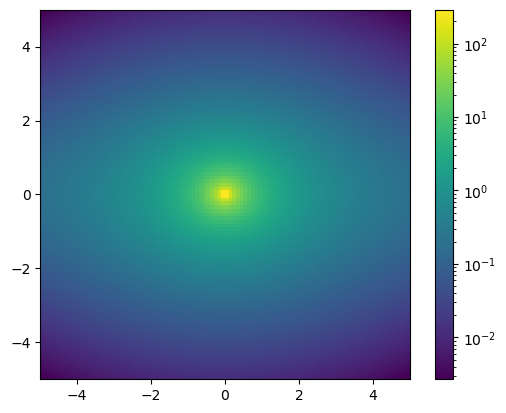

In [15]:
def create_dummy_image(p_a_def,p_b_def,p_c_def,p_d_def,error_fraction):
    s_def = 1. 

    e_k_def = 0.0 
    e_d_def = 0.0

    q_a_def = 0.0
    q_b_def = 0.0
    q_c_def = 0.0
    q_d_def = 0.6

    a_def = 2.
    b_def = 4.
    rho0_def = 1.
    i_def = 0.
    phi_def = 0.
    theta_def = 0.

    size = 100
    extent = 5
    extents = [-extent, extent,-extent, extent]



    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
    plt.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
    plt.colorbar()

    key = jax.random.PRNGKey(42)
    noise = jax.random.normal(key, shape=sb_1.data.shape) * (error_fraction * sb_1.data)
    noisy_data = jnp.clip(sb_1.data + noise, 1e-6, None)


    return noisy_data, extents,size

p_a_def = 0.#0.00160907
p_b_def = 0.#-0.02122767
p_c_def = -0.088#0.07711992
p_d_def = 0.9#0.54249868

noisy_data, extents, size = create_dummy_image(p_a_def,p_b_def,p_c_def,p_d_def,0.2)


#noisy_data = np.zeros_like(noisy_data)

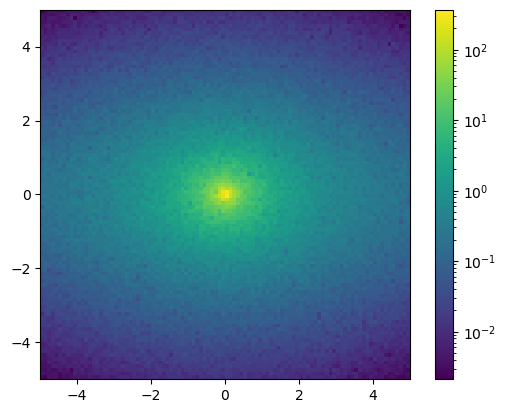

In [16]:
plt.imshow(noisy_data.T, norm=LogNorm(), origin='lower',extent = extents)
plt.colorbar()

In [17]:

#np.min(sb_1.data+noise)

In [18]:
#sb_1.x_coord

In [19]:
#try rho funcction that we use in package

def rho(x, y, z, e, p, q, rho0, s, a, b):
    #eps = 1e-12
    #r = (jnp.abs(x)**2 + jnp.abs(y)**2 + jnp.abs(z)**2)**0.5
    m = ((jnp.abs(x)**(2 - e) + (jnp.abs(y) / p)**(2 - e) + (jnp.abs(z) / q)**(2 - e)))**(1 / (2 - e)) 
    #m = jnp.maximum(m, eps)
    den = rho0 / ((m / s)**a * (1 + (m / s))**(b - a))
    return den / (p * q)

In [20]:
from JAX_Deprojection import utils

numpyro.enable_validation(is_validate=True)

# create r array smallest smaller than grid biggest bigger with ~100 points
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)
    #r = jnp.maximum(r,eps)
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,1. ,low = 0.01,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.TruncatedNormal(0.,0.5,low = 0.01)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))

    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    # Constant parameters
    q = 0.6
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = 2.0
    b = 4.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, 0., 0., 0.)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.Normal(sb, 0.2 * sb), obs=sigma_obs)




# write email to sudeshna

#works until ~2500 steps
#change ab to 2 and 4

# skip gp do sample p use restricted prior, uniform 0 and 1, dont need deterministic
# autodelta guide just best solution without uncertainty
# less steps
#sample predictive and see if model performs correctly by inputing params by hand


In [21]:
def runsvi(adam,elbo,noisy_data,steps,rho_x,rho_y,rho_z,r):# Use AutoGuide for variational inference
    guide = AutoNormal(model)

    # Optimizer and inference
    optim = Adam(adam)
    svi = SVI(model, guide, optim, Trace_ELBO(elbo))
    key = jax.random.PRNGKey(42)

    results = svi.run(key, steps, rho_x,rho_y,rho_z,r, sigma_obs=noisy_data)

    return results, guide 

#maybe use svi step instead of svi run to use dynamic step number and prevent loss from going to infinity

In [22]:
#steps = 500
extent = extents[1]

x,y = jnp.meshgrid(jnp.linspace(-extent,extent,size),jnp.linspace(-extent,extent,size),indexing='ij')

x = x.flatten()
y = y.flatten()
grid_size = jnp.astype(jnp.sqrt(len(x)),jnp.int32)

rho_x,rho_y,rho_z = utils.create_grid(grid_size,jnp.max(x))
r = jnp.sqrt(rho_x**2 + rho_y**2 + rho_z**2)

r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

#results, guide = runsvi(0.1,1,noisy_data,steps,rho_x,rho_y,rho_z,r)

In [23]:
def p(r,p_a,p_b,p_c,p_d):
    p = p_a * r**3 + p_b * r**2 + p_c * r + p_d
    return p

def plot_p_sample(adam,elbo,steps,p_mean,p_std,r_gp,p_a_def,p_b_def,p_c_def,p_d_def):
    
    p_obs = p(r_gp,p_a_def,p_b_def,p_c_def,p_d_def)


    # Plot p(r)
    plt.figure(figsize=(8, 6))
    plt.plot(r_gp, p_mean, label="Predicted p(r)")
    plt.plot(r_gp,p_obs, label="True p(r)")
    #plt.errorbar(r_gp,p_mean, yerr = p_std,ecolor ="blue")
    plt.fill_between(r_gp, p_mean - p_std, p_mean + p_std, alpha=0.2, label="Uncertainty")
    plt.xlabel("Radial distance (r)")
    plt.ylabel("p(r)")
    plt.title("Predicted p as a function of radial distance: Stepsize {}, Elbo {}, Steps {}".format(adam,elbo,steps))
    plt.legend()
    plt.grid(True)
    plt.ylim(0,1)
    plt.show()

def plot_comparison(adam,elbo,steps,noisy_data,p_mean,sb_mean,sb_std,p_a_def,p_b_def,p_c_def,p_d_def):


    interpolator = RegularGridInterpolator((r_gp,), p_mean, method="linear", bounds_error=False, fill_value=None)
    # Interpolate the values

    sorting_indices = jnp.argsort(r)  # Get indices that sort r_obs
    r_sorted = r[sorting_indices]  # Sort r_obs

    #p_sampled_full = interpolator(r)

    p_sampled_full_sorted = interpolator(r_sorted)
    p_obs = p(r_sorted,p_a_def,p_b_def,p_c_def,p_d_def)


    # Set up the figure and subplots
    fig, axes = plt.subplots(4, figsize=(8,16))


    #key = jax.random.PRNGKey(42)

    # Plot data in each subplot


    ax1 = axes[0]
    ax2 = axes[1]
    ax3 = axes[2]
    ax4 = axes[3]

    img1 = ax1.imshow(noisy_data.T, norm=colors.LogNorm(vmin=noisy_data.min(), vmax=noisy_data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale')
    ax1.set_title("True p_a: "+str(p_a_def)+" True p_b: "+str(p_b_def)+" True p_c: "+str(p_c_def)+" True p_d: "+str(p_d_def))

    img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale')
    ax2.set_title("With predicted p using model parameters: Stepsize {}, Elbo {}, Steps {}".format(adam,elbo,steps))

    residual = (noisy_data - sb_mean)/sb_mean
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale')
    score = utils.ssd_score(noisy_data,sb_mean,sb_mean)
    ax3.set_title("Residual Score: "+str(score))

    ax4.plot(r_sorted, p_obs, label="True function of p(r)")
    ax4.plot(r_sorted, p_sampled_full_sorted, label="Predicted function of p(r)")

    ax4.legend()
    ax4.set_xlabel('r')
    ax4.set_ylabel('p(r)')
    ax4.grid(True)
    ax4.set_ylim([0,1])


    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()



0.1 2 500


100%|██████████| 500/500 [02:31<00:00,  3.29it/s, init loss: 58911968.0000, avg. loss [476-500]: -11674.1694]


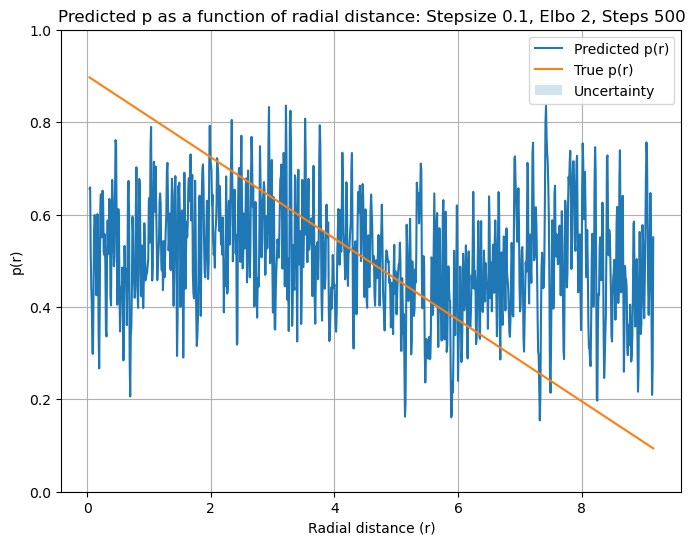

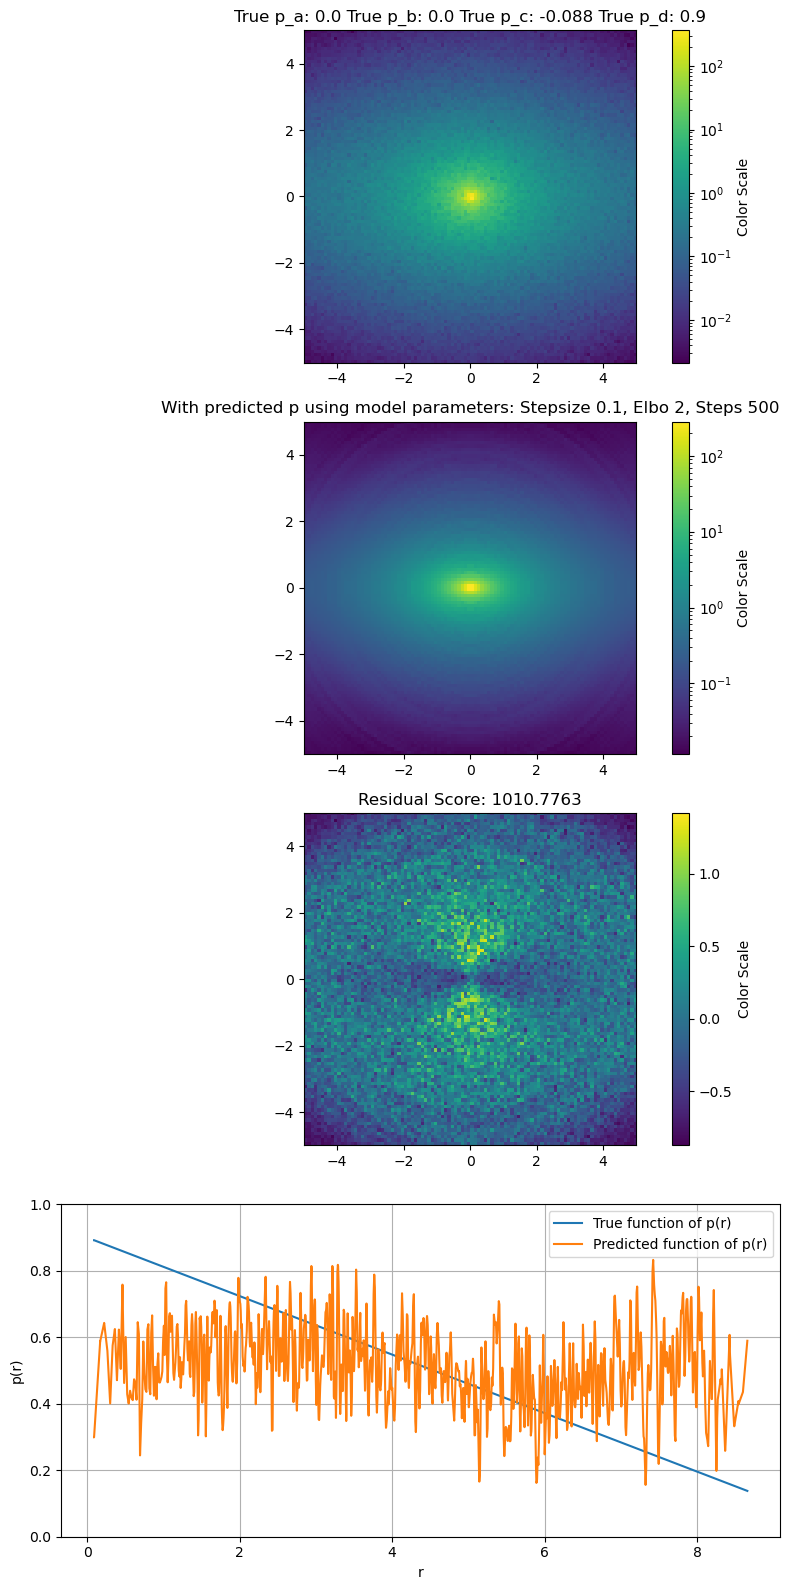

0.1 10 500


100%|██████████| 500/500 [06:56<00:00,  1.20it/s, init loss: 58726300.0000, avg. loss [476-500]: -11309.5354]


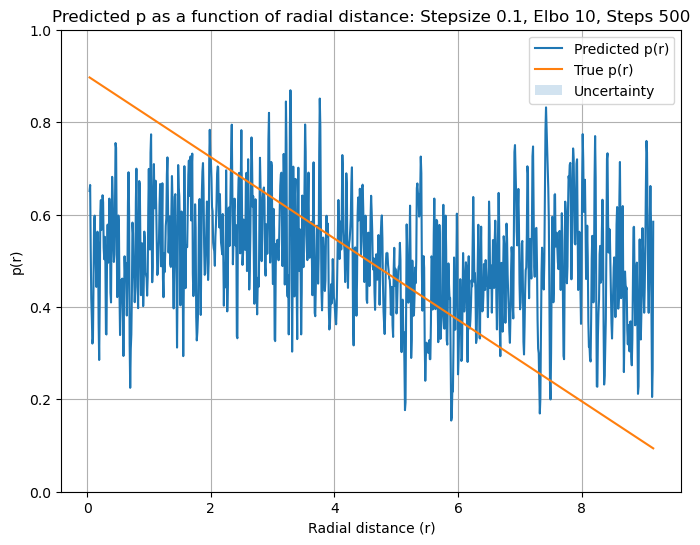

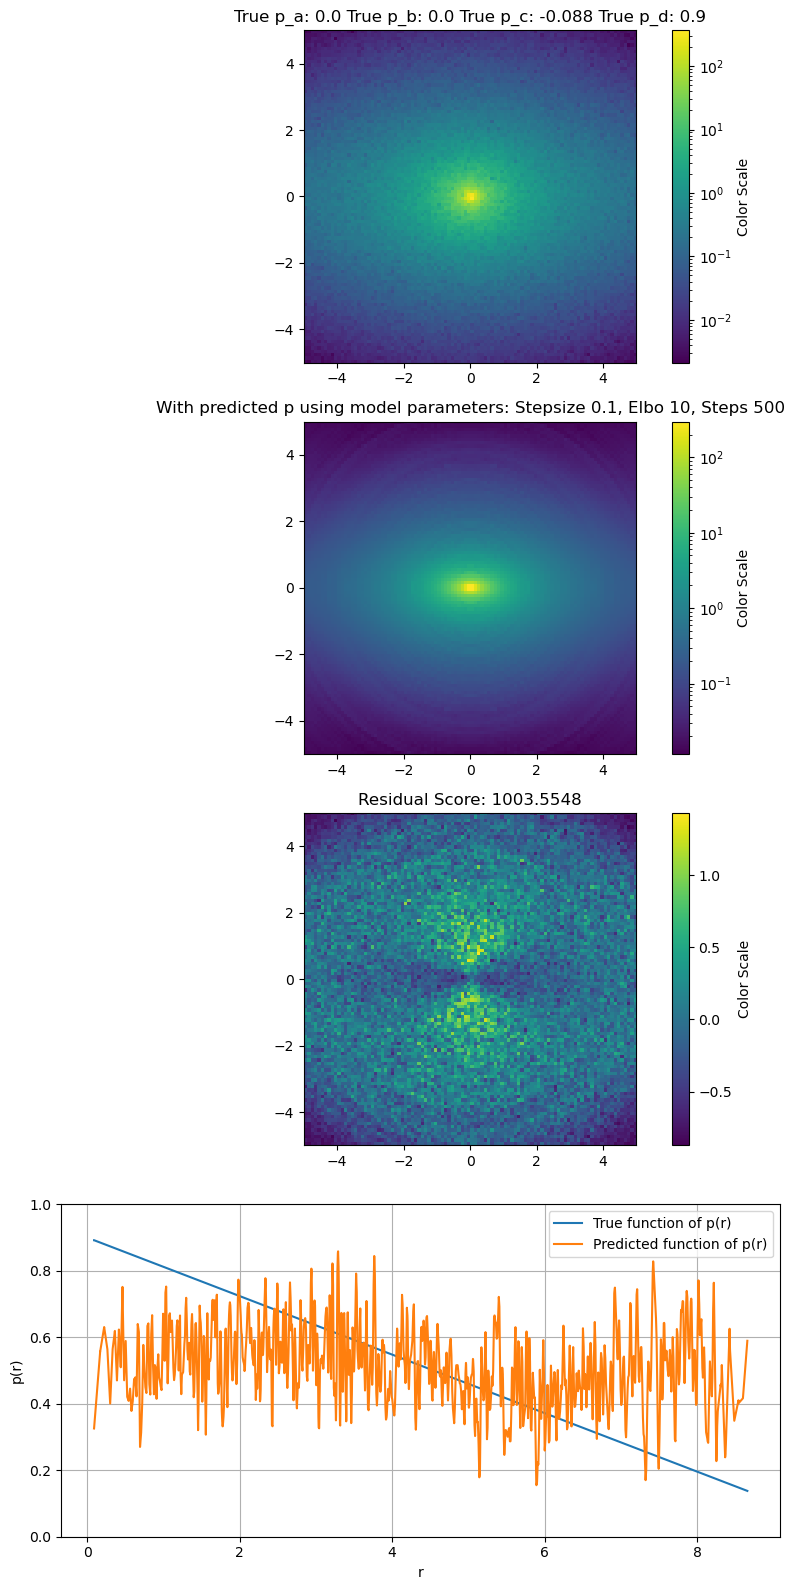

In [24]:
adam_params = [0.1]
elbo_params = [2,10]
steps_param = [500]

for i in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            print(adam_params[i],elbo_params[j],steps_param[k])
            results, guide = runsvi(adam_params[i],elbo_params[j],noisy_data,steps_param[k],rho_x,rho_y,rho_z,r)

            key = jax.random.PRNGKey(42)

            predictive = Predictive(guide, params=results.params, num_samples=1000)
            posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

            predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
            posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


            p_mean = posterior_predictive_samples['p'].mean(axis=0)
            p_std = posterior_predictive_samples['p'].std(axis=0)

            sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
            sb_std = posterior_predictive_samples['sb'].std(axis=0)

            plot_p_sample(adam_params[i],elbo_params[j],steps_param[k],p_mean,p_std,r_gp,p_a_def,p_b_def,p_c_def,p_d_def)

            plot_comparison(adam_params[i],elbo_params[j],steps_param[k],noisy_data,p_mean,sb_mean,sb_std,p_a_def,p_b_def,p_c_def,p_d_def)
            

In [25]:
#numpyro.render_model(model, model_args=(rho_x,rho_y,rho_z,r))

0.2 10 500


100%|██████████| 500/500 [07:31<00:00,  1.11it/s, init loss: 58726300.0000, avg. loss [476-500]: -13013.6521]


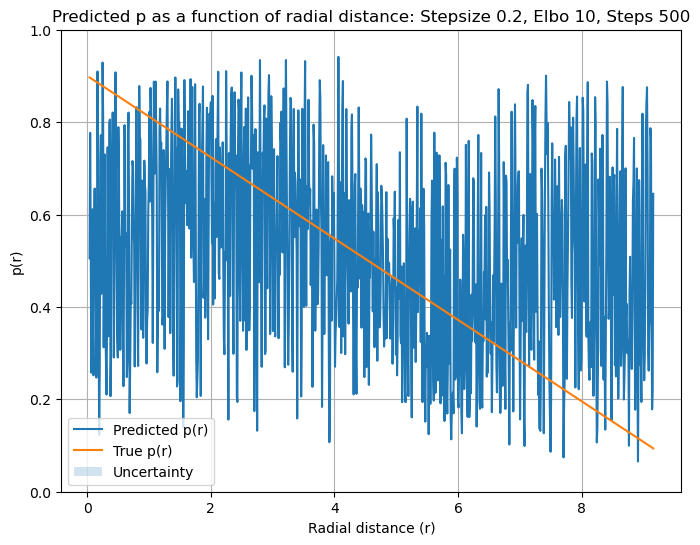

z:\anaconda3\envs\new_env\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


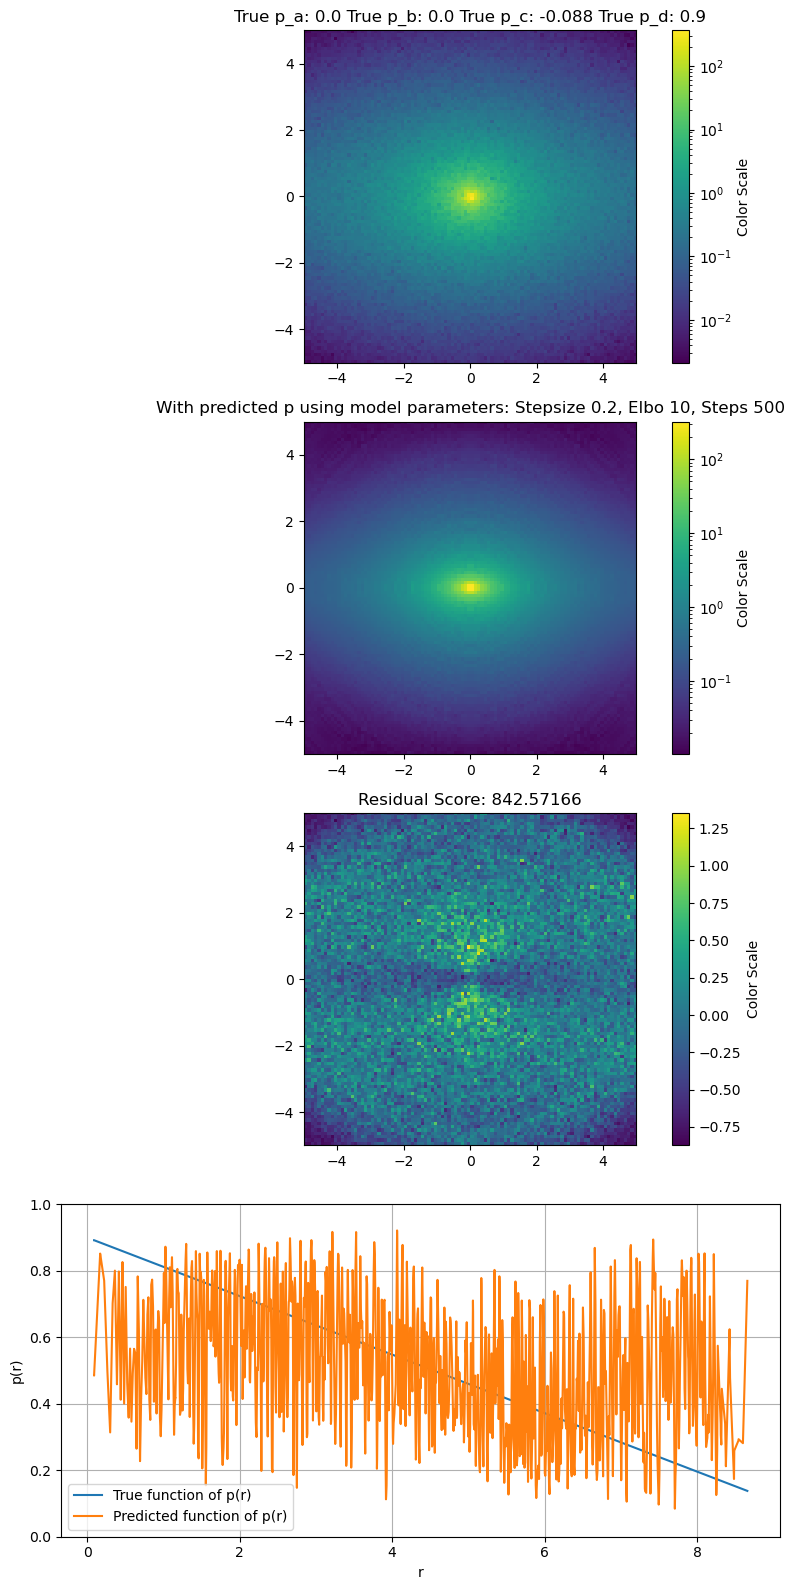

0.2 10 1000


100%|██████████| 1000/1000 [15:07<00:00,  1.10it/s, init loss: 58726300.0000, avg. loss [951-1000]: -17589.6395]


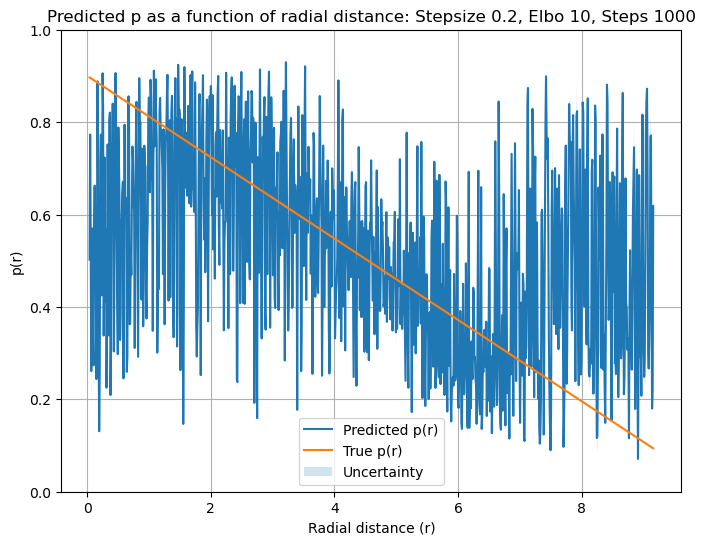

C:\Users\marco\AppData\Local\Temp\ipykernel_21212\961136513.py:78: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


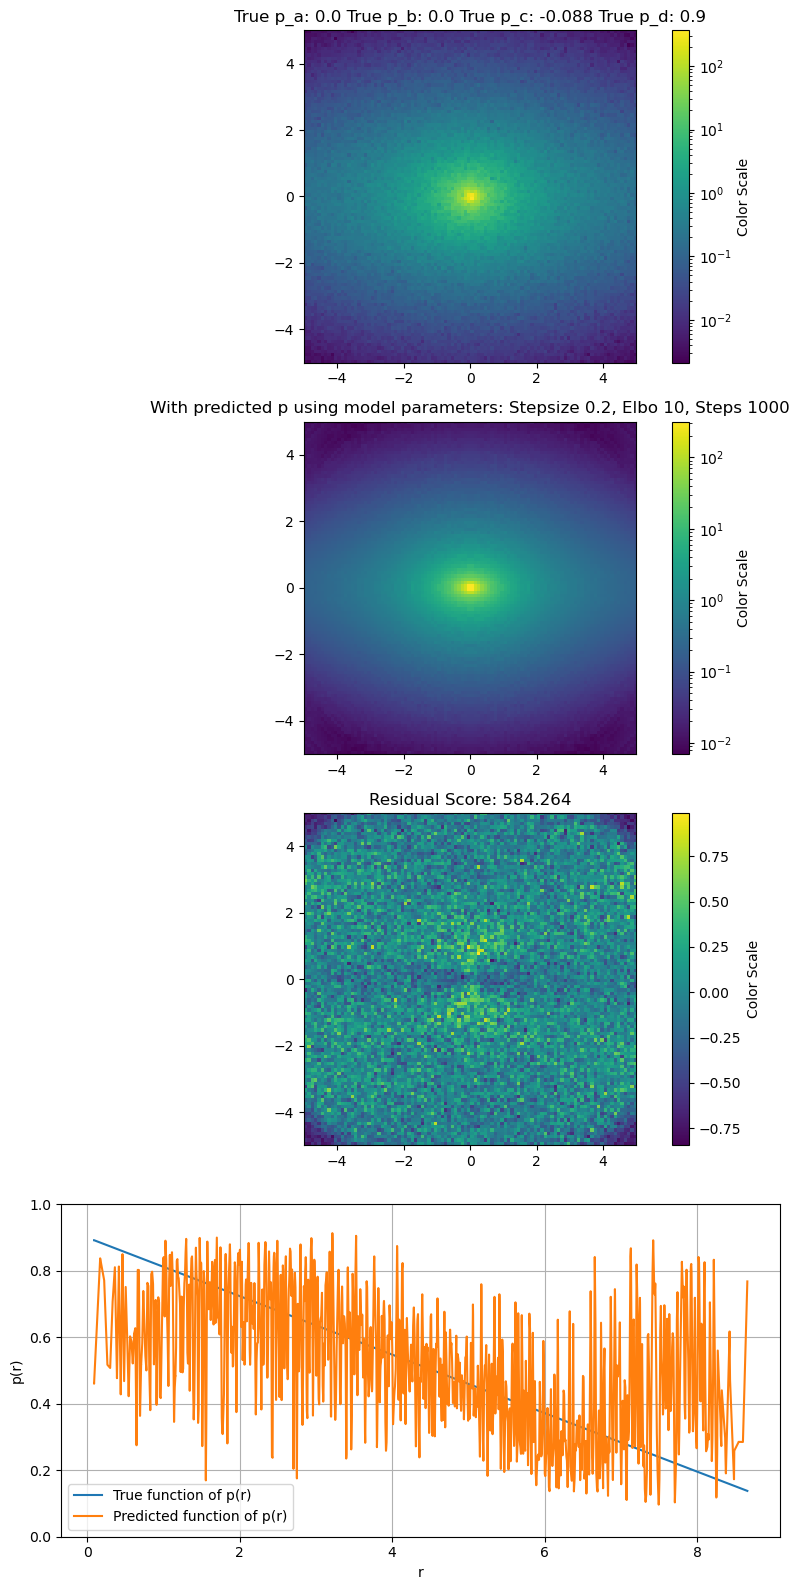

In [26]:
adam_params = [0.2]
elbo_params = [10]
steps_param = [500,1000]

for i in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            print(adam_params[i],elbo_params[j],steps_param[k])
            results, guide = runsvi(adam_params[i],elbo_params[j],noisy_data,steps_param[k],rho_x,rho_y,rho_z,r)

            key = jax.random.PRNGKey(42)

            predictive = Predictive(guide, params=results.params, num_samples=1000)
            posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

            predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
            posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


            p_mean = posterior_predictive_samples['p'].mean(axis=0)
            p_std = posterior_predictive_samples['p'].std(axis=0)

            sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
            sb_std = posterior_predictive_samples['sb'].std(axis=0)

            plot_p_sample(adam_params[i],elbo_params[j],steps_param[k],p_mean,p_std,r_gp,p_a_def,p_b_def,p_c_def,p_d_def)

            plot_comparison(adam_params[i],elbo_params[j],steps_param[k],noisy_data,p_mean,sb_mean,sb_std,p_a_def,p_b_def,p_c_def,p_d_def)

In [66]:
results.params.keys()

dict_keys(['length_scale_p_auto_loc', 'length_scale_p_auto_scale', 'p_not_transformed_auto_loc', 'p_not_transformed_auto_scale', 'sigma_p_auto_loc', 'sigma_p_auto_scale'])

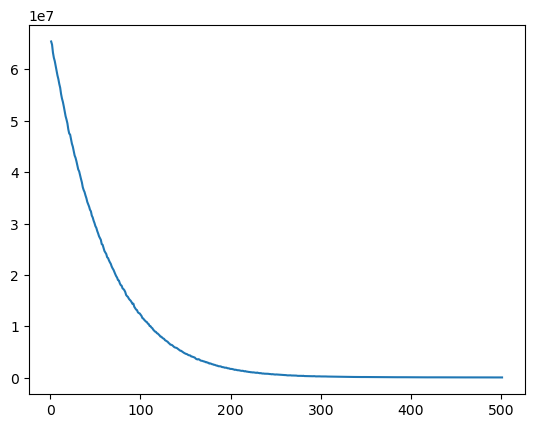

In [67]:
loss = results.losses
num_steps = np.linspace(1,steps+1,steps)

plt.plot(num_steps,loss)

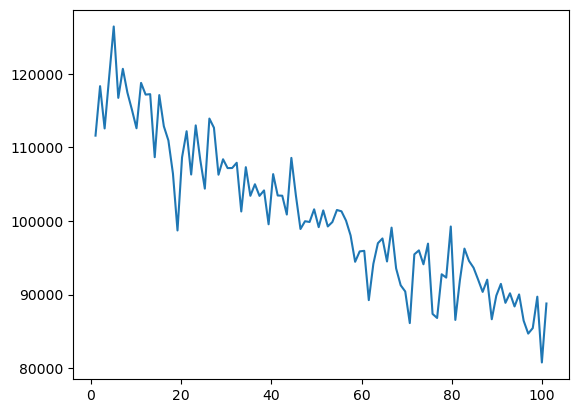

In [68]:
loss_last_steps = loss[-100:]
num_steps = np.linspace(1,101,100)
plt.plot(num_steps,loss_last_steps)

In [69]:
key = jax.random.PRNGKey(42)

   
predictive = Predictive(guide, params=results.params, num_samples=1000)
posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

#plt.hist(posterior_samples['p_not_transformed'])
#posterior_samples

In [70]:

predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


p_mean = posterior_predictive_samples['p'].mean(axis=0)
p_std = posterior_predictive_samples['p'].std(axis=0)

sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
sb_std = posterior_predictive_samples['sb'].std(axis=0)


In [71]:
posterior_predictive_samples['p'].shape

(1000, 1000)

In [72]:
#sample = sample_p(results,model)
#sample['p'].shape

In [73]:
#len(sample['p'][0])

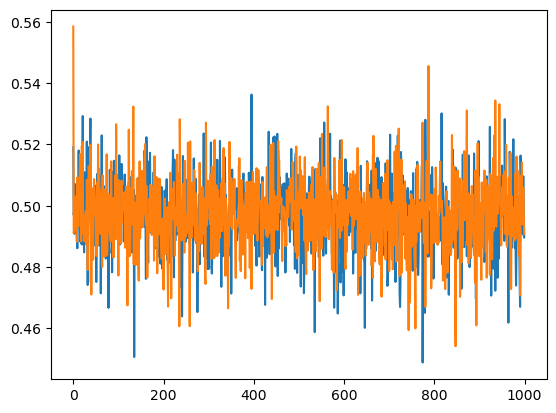

In [74]:
plt.plot(posterior_predictive_samples['p'][0])
plt.plot(posterior_predictive_samples['p'][1000])

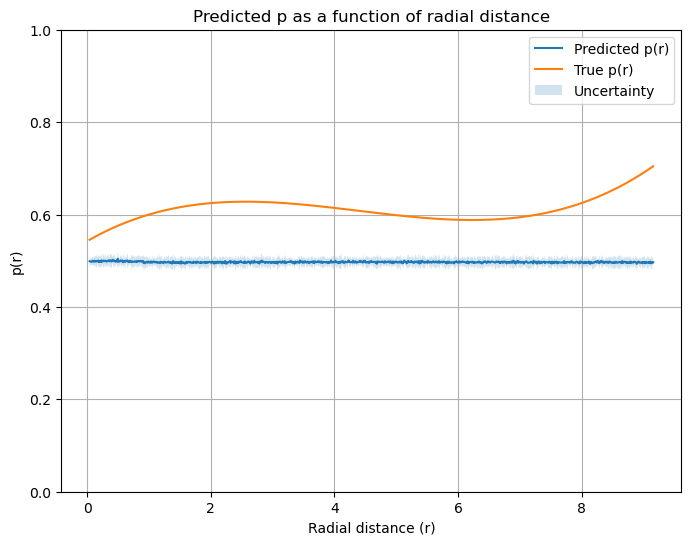

In [75]:




def p(r,p_a,p_b,p_c,p_d):
    p = p_a * r**3 + p_b * r**2 + p_c * r + p_d
    return p

r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

def plot_p_sample(p_mean,p_std,r_gp,p_a_def,p_b_def,p_c_def,p_d_def):
    
    p_obs = p(r_gp,p_a_def,p_b_def,p_c_def,p_d_def)


    # Plot p(r)
    plt.figure(figsize=(8, 6))
    plt.plot(r_gp, p_mean, label="Predicted p(r)")
    plt.plot(r_gp,p_obs, label="True p(r)")
    #plt.errorbar(r_gp,p_mean, yerr = p_std,ecolor ="blue")
    plt.fill_between(r_gp, p_mean - p_std, p_mean + p_std, alpha=0.2, label="Uncertainty")
    plt.xlabel("Radial distance (r)")
    plt.ylabel("p(r)")
    plt.title("Predicted p as a function of radial distance")
    plt.legend()
    plt.grid(True)
    plt.ylim(0,1)
    plt.show()


plot_p_sample(p_mean,p_std,r_gp,p_a_def,p_b_def,p_c_def,p_d_def)

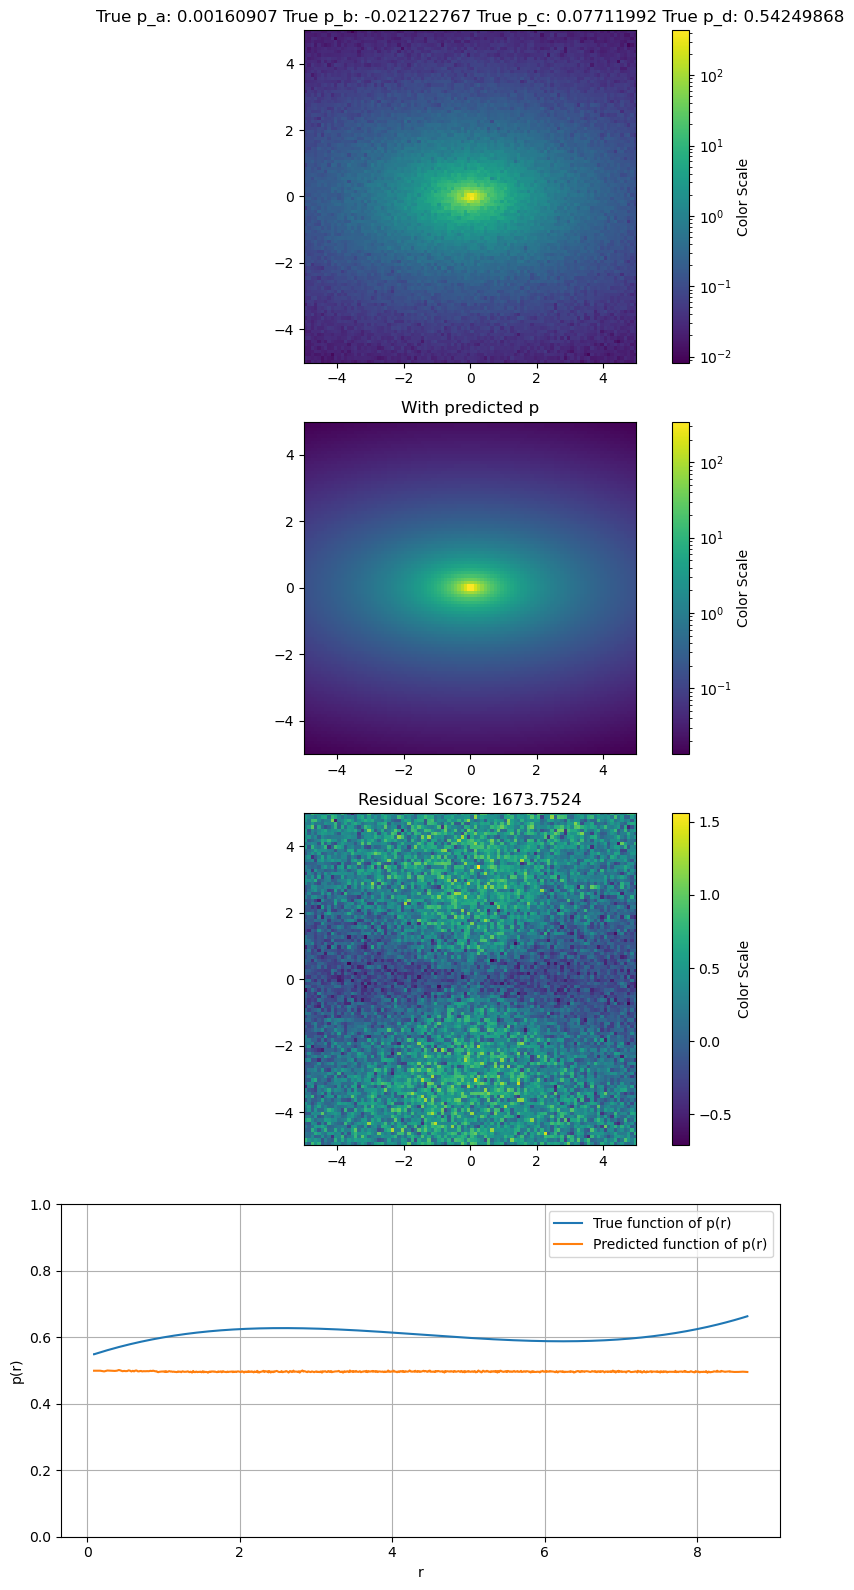

In [76]:
def plot_comparison(noisy_data,p_mean,sb_mean,sb_std,p_a_def,p_b_def,p_c_def,p_d_def):


    interpolator = RegularGridInterpolator((r_gp,), p_mean, method="linear", bounds_error=False, fill_value=None)
    # Interpolate the values

    sorting_indices = jnp.argsort(r)  # Get indices that sort r_obs
    r_sorted = r[sorting_indices]  # Sort r_obs

    #p_sampled_full = interpolator(r)

    p_sampled_full_sorted = interpolator(r_sorted)
    p_obs = p(r_sorted,p_a_def,p_b_def,p_c_def,p_d_def)


    # Set up the figure and subplots
    fig, axes = plt.subplots(4, figsize=(8,16))


    #key = jax.random.PRNGKey(42)

    # Plot data in each subplot


    ax1 = axes[0]
    ax2 = axes[1]
    ax3 = axes[2]
    ax4 = axes[3]



    img1 = ax1.imshow(noisy_data.T, norm=colors.LogNorm(vmin=noisy_data.min(), vmax=noisy_data.max()), origin='lower',extent = extents)
    fig.colorbar(img1, ax=ax1, label='Color Scale')
    ax1.set_title("True p_a: "+str(p_a_def)+" True p_b: "+str(p_b_def)+" True p_c: "+str(p_c_def)+" True p_d: "+str(p_d_def))

    img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
    fig.colorbar(img2, ax=ax2, label='Color Scale')
    ax2.set_title("With predicted p")

    residual = (noisy_data - sb_mean)/sb_mean
    img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
    fig.colorbar(img3, ax=ax3, label='Color Scale')
    score = utils.ssd_score(noisy_data,sb_mean,sb_mean)
    ax3.set_title("Residual Score: "+str(score))

    ax4.plot(r_sorted, p_obs, label="True function of p(r)")
    ax4.plot(r_sorted, p_sampled_full_sorted, label="Predicted function of p(r)")

    ax4.legend()
    ax4.set_xlabel('r')
    ax4.set_ylabel('p(r)')
    ax4.grid(True)
    ax4.set_ylim([0,1])


    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()


plot_comparison(noisy_data,p_mean,sb_mean,sb_std,p_a_def,p_b_def,p_c_def,p_d_def)